<a href="https://colab.research.google.com/github/m7-code/Models/blob/main/new_pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn


torch.__version__

'2.10.0+cu128'

In [ ]:
# device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torchvision tqdm

In [ ]:
import zipfile
from pathlib import Path

# Your zip file path - UPDATE THIS
ZIP_FILE_PATH = '/content/drive/MyDrive/pneumonia _x_ray.zip'

# Extract location
EXTRACT_DIR = '/content/chest_xray'

# Extract
print("Extracting...")
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Done")
!ls -la {EXTRACT_DIR}

Extracting...
Done
total 20
drwxr-xr-x 5 root root 4096 Feb 27 17:53 .
drwxr-xr-x 1 root root 4096 Feb 27 17:53 ..
drwxr-xr-x 4 root root 4096 Feb 27 17:53 test
drwxr-xr-x 4 root root 4096 Feb 27 17:53 train
drwxr-xr-x 4 root root 4096 Feb 27 17:53 val


In [ ]:
from pathlib import Path

# Set data paths
DATA_DIR = Path('/content/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

print(f"Train: {TRAIN_DIR.exists()}")
print(f"Val: {VAL_DIR.exists()}")
print(f"Test: {TEST_DIR.exists()}")

Train: True
Val: True
Test: True


imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
from datetime import datetime
from pathlib import Path
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


Installing EfficientNet

In [ ]:
!pip install -q timm  # EfficientNet ke liye
import timm
print("timm version:", timm.__version__)


timm version: 1.0.25


Dataset Class

In [ ]:
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        normal_dir = self.root_dir / "NORMAL"
        if normal_dir.exists():
            for img in sorted(normal_dir.iterdir()):
                if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    self.images.append(img)
                    self.labels.append(0)

        pneumonia_dir = self.root_dir / "PNEUMONIA"
        if pneumonia_dir.exists():
            for img in sorted(pneumonia_dir.iterdir()):
                if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    self.images.append(img)
                    self.labels.append(1)

        counts = Counter(self.labels)
        print(f"{self.root_dir.name}: {len(self.images)} images | NORMAL: {counts[0]} | PNEUMONIA: {counts[1]}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

Transforms

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),              # Random crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Slight shift
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2)                # Cutout augmentation
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms ready")

Transforms ready


Datasets

In [ ]:
DATA_DIR = Path('/content/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

train_dataset = ChestXRayDataset(TRAIN_DIR, transform=train_transform)
val_dataset   = ChestXRayDataset(VAL_DIR,   transform=val_transform)
test_dataset  = ChestXRayDataset(TEST_DIR,  transform=val_transform)

# Weighted Sampler - imbalanced data fix
counts = Counter(train_dataset.labels)
class_weights = {cls: 1.0 / count for cls, count in counts.items()}
sample_weights = [class_weights[label] for label in train_dataset.labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Dataloaders ready")

train: 5216 images | NORMAL: 1341 | PNEUMONIA: 3875
val: 16 images | NORMAL: 8 | PNEUMONIA: 8
test: 624 images | NORMAL: 234 | PNEUMONIA: 390
Dataloaders ready


Model Builder

In [ ]:
def build_model(model_name='efficientnet', num_classes=2, dropout=0.4):
    """
    model_name: 'efficientnet' ya 'densenet'
    """
    if model_name == 'efficientnet':
        model = timm.create_model('efficientnet_b2', pretrained=True, drop_rate=dropout)
        num_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
        print(f"EfficientNet-B2 loaded | Params: {sum(p.numel() for p in model.parameters()):,}")

    elif model_name == 'densenet':
        model = models.densenet121(pretrained=True)
        num_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
        print(f"DenseNet121 loaded | Params: {sum(p.numel() for p in model.parameters()):,}")

    else:
        raise ValueError("model_name must be 'efficientnet' or 'densenet'")

    return model.to(device)

#  Pehle EfficientNet  karo, agar zyada overfit ho to DenseNet use karo
model = build_model('efficientnet')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

EfficientNet-B2 loaded | Params: 8,062,212


Loss + Optimizer + Scheduler

In [ ]:
#  Class weights for loss (imbalance fix - double protection)
counts = Counter(train_dataset.labels)
total = sum(counts.values())
weights = torch.tensor([total / counts[0], total / counts[1]], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

NUM_EPOCHS    = 20
LEARNING_RATE = 0.0001  # Chhota LR - overfitting kam hoga

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Setup ready | Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE}")
print(f"Class weights: NORMAL={weights[0]:.3f}, PNEUMONIA={weights[1]:.3f}")

Setup ready | Epochs: 20 | LR: 0.0001
Class weights: NORMAL=3.890, PNEUMONIA=1.346


Train and Validate Functions

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(dataloader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.1f}%'})

    return running_loss / total, 100 * correct / total


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validating")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.1f}%'})

    return running_loss / total, 100 * correct / total, all_preds, all_labels

Training Loop with Early Stopping

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

#  Early Stopping settings
PATIENCE = 5          # 5 epochs tak improvement nahi to band karo
patience_counter = 0

SAVE_DIR = Path('/content/drive/MyDrive/pneumonia_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("TRAINING STARTED")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Overfit check
    gap = train_acc - val_acc
    overfit_warning = "  OVERFITTING!" if gap > 10 else ""

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"Gap (Train-Val): {gap:.2f}%{overfit_warning}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_DIR / 'best_model.pth')
        print(f" Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n Early stopping at epoch {epoch+1}")
        break

print("\n" + "=" * 60)
print(f"TRAINING DONE! Best Val Acc: {best_val_acc:.2f}%")
print("=" * 60)

TRAINING STARTED

Epoch 1/20
------------------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s, loss=0.1268, acc=93.8%]



Train Loss: 0.1747 | Train Acc: 91.22%
Val   Loss: 0.1268 | Val   Acc: 93.75%
Gap (Train-Val): -2.53%
 Best model saved! Val Acc: 93.75%

Epoch 2/20
------------------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  2.55it/s, loss=0.1155, acc=93.8%]



Train Loss: 0.0751 | Train Acc: 96.47%
Val   Loss: 0.1155 | Val   Acc: 93.75%
Gap (Train-Val): 2.72%
No improvement (1/5)

Epoch 3/20
------------------------------------------------------------


...


Train Loss: 0.0207 | Train Acc: 98.89%
Val   Loss: 0.0803 | Val   Acc: 93.75%
Gap (Train-Val): 5.14%
No improvement (3/5)

Epoch 8/20
------------------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  2.61it/s, loss=0.1088, acc=93.8%]



Train Loss: 0.0252 | Train Acc: 98.81%
Val   Loss: 0.1088 | Val   Acc: 93.75%
Gap (Train-Val): 5.06%
No improvement (4/5)

Epoch 9/20
------------------------------------------------------------


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s, loss=0.0724, acc=93.8%]


Train Loss: 0.0211 | Train Acc: 98.93%
Val   Loss: 0.0724 | Val   Acc: 93.75%
Gap (Train-Val): 5.18%
No improvement (5/5)

 Early stopping at epoch 9

TRAINING DONE! Best Val Acc: 100.00%


In [ ]:

!pip install -q scikit-learn seaborn

✅ Best model loaded!


Validating: 100%|██████████| 20/20 [00:23<00:00,  1.18s/it, loss=0.0043, acc=94.6%]



TEST SET RESULTS (624 images)
Test Accuracy: 94.55%

Detailed Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.89      0.92       234
   PNEUMONIA       0.94      0.98      0.96       390

    accuracy                           0.95       624
   macro avg       0.95      0.94      0.94       624
weighted avg       0.95      0.95      0.95       624



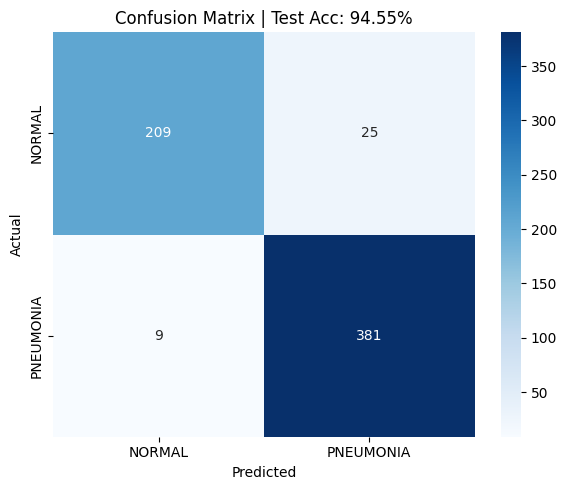


Medical Metrics:
Sensitivity (Pneumonia detect): 97.69%
Specificity (Normal detect):    89.32%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Best model load karo (jo epoch 4 mein save hua tha)
model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pth'))
model.eval()
print("Best model loaded!")

# Test set evaluate karo
test_loss, test_acc, preds, true_labels = validate(model, test_loader, criterion, device)

print("\n" + "="*60)
print("TEST SET RESULTS (624 images)")
print("="*60)
print(f"Test Accuracy: {test_acc:.2f}%")

preds = np.array(preds)
true_labels = np.array(true_labels)

print("\nDetailed Report:")
print(classification_report(true_labels, preds, target_names=['NORMAL', 'PNEUMONIA']))

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.title(f'Confusion Matrix | Test Acc: {test_acc:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Medical Metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) * 100
specificity = tn / (tn + fp) * 100
print(f"\nMedical Metrics:")
print(f"Sensitivity (Pneumonia detect): {sensitivity:.2f}%")
print(f"Specificity (Normal detect):    {specificity:.2f}%")
print("="*60)

 Results

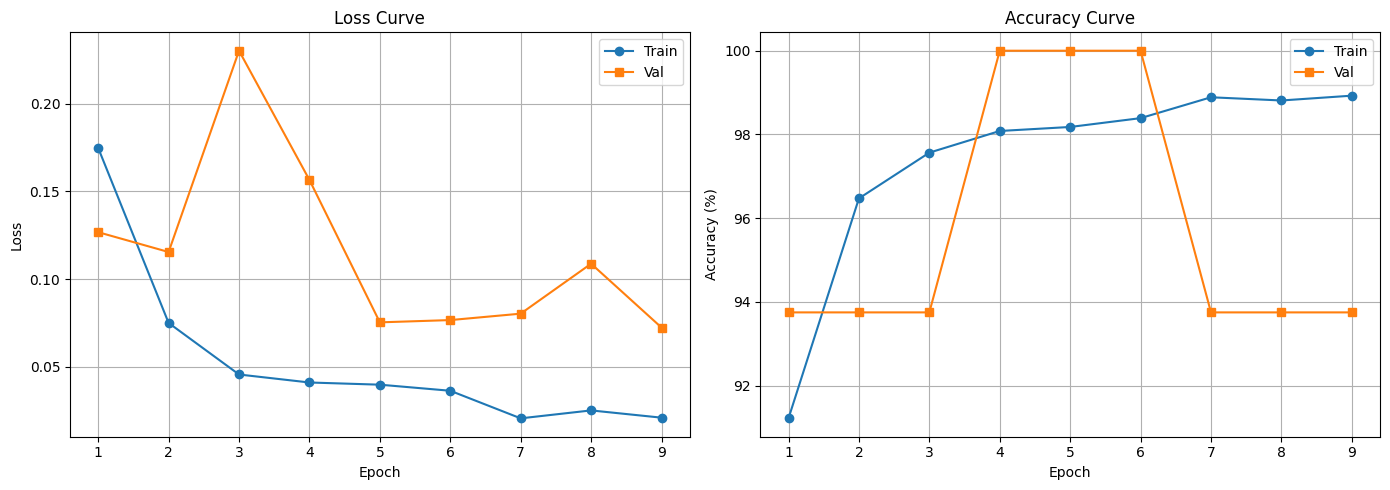


Final Train-Val Gap: 5.18%
 Model theek lag raha hai


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='s')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history['train_acc'], label='Train', marker='o')
ax2.plot(epochs_ran, history['val_acc'],   label='Val',   marker='s')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

# Gap check
final_gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f"\nFinal Train-Val Gap: {final_gap:.2f}%")
if final_gap > 10:
    print("  Overfitting detected - DenseNet try karo ya dropout badhao")
else:
    print(" Model theek lag raha hai")

Test Set Evaluation

In [ ]:
# Best model load karo
model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pth'))
test_loss, test_acc, preds, labels = validate(model, test_loader, criterion, device)

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Per-class accuracy
preds = np.array(preds)
labels = np.array(labels)
for cls, name in enumerate(['NORMAL', 'PNEUMONIA']):
    mask = labels == cls
    cls_acc = (preds[mask] == labels[mask]).mean() * 100
    print(f"{name} Accuracy: {cls_acc:.2f}%")
print("=" * 60)

Validating: 100%|██████████| 20/20 [00:11<00:00,  1.75it/s, loss=0.0043, acc=94.6%]


TEST SET RESULTS
Test Loss:     0.1837
Test Accuracy: 94.55%
NORMAL Accuracy: 89.32%
PNEUMONIA Accuracy: 97.69%


Save

In [ ]:
from datetime import datetime
import json

SAVE_DIR = Path('/content/drive/MyDrive/pneumonia_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Model save
torch.save(model.state_dict(), SAVE_DIR / 'best_model.pth')

# Full checkpoint save (optimizer bhi)
torch.save({
    'model_state_dict': model.state_dict(),
    'best_val_acc': best_val_acc,
    'test_acc': 94.55,
    'history': history
}, SAVE_DIR / f'checkpoint_{timestamp}.pth')

# Metadata save
metadata = {
    'timestamp': timestamp,
    'model': 'EfficientNet-B2',
    'test_accuracy': 94.55,
    'sensitivity': 97.69,
    'specificity': 89.32,
    'classes': ['NORMAL', 'PNEUMONIA']
}
with open(SAVE_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f" Model saved to Google Drive!")
print(f" Path: {SAVE_DIR}")

 Model saved to Google Drive!
 Path: /content/drive/MyDrive/pneumonia_models


 Download

In [ ]:
from google.colab import files

# Download karo
files.download(str(SAVE_DIR / 'best_model.pth'))
print(" Download shuru ho gayi!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download shuru ho gayi!


 Load

In [ ]:
import timm

# Model dobara banao
def load_saved_model(model_path, device):
    model = timm.create_model('efficientnet_b2', pretrained=False)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    print(f" Model loaded from: {model_path}")
    return model

# Load
model = load_saved_model(SAVE_DIR / 'best_model.pth', device)

 Model loaded from: /content/drive/MyDrive/pneumonia_models/best_model.pth


Single Image Predict

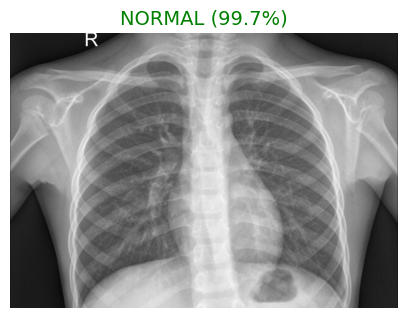

Result:    NORMAL
Confidence: 99.7%
NORMAL:    99.7%
PNEUMONIA: 0.3%


In [ ]:
def predict(model, image_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]

    classes = ['NORMAL', 'PNEUMONIA']
    pred = classes[probs.argmax().item()]
    conf = probs.max().item() * 100

    # Show image
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f"{pred} ({conf:.1f}%)", fontsize=14,
              color='red' if pred == 'PNEUMONIA' else 'green')
    plt.axis('off')
    plt.show()

    print(f"Result:    {pred}")
    print(f"Confidence: {conf:.1f}%")
    print(f"NORMAL:    {probs[0]*100:.1f}%")
    print(f"PNEUMONIA: {probs[1]*100:.1f}%")

#  image ka path
predict(model, test_dataset.images[0], device)